In [892]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import math
import statsmodels.api as sm
np.random.seed(0)

In [893]:
test = pd.read_csv('D:/mythings/Dataset/HousePrice/Housing Prices Competition for Kaggle Learn Users/test.csv')
train = pd.read_csv('D:/mythings/Dataset/HousePrice/Housing Prices Competition for Kaggle Learn Users/train.csv')

In [894]:
test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [895]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [896]:
#LotFrontage
LotFrontage_avg_train = train['LotFrontage'].mean()
LotFrontage_avg_test = test['LotFrontage'].mean()
train['LotFrontage'] = train['LotFrontage'].fillna(LotFrontage_avg_train)
test['LotFrontage'] = test['LotFrontage'].fillna(LotFrontage_avg_test)
#BsmtExposure
train.loc[948,'BsmtExposure'] = 'No'
test.loc[27,'BsmtExposure'] = 'No'
test.loc[888,'BsmtExposure'] = 'No'
#TotalBsmtSF
TotalBsmt_avg_train = train['TotalBsmtSF'].mean()
TotalBsmt_avg_test = test['TotalBsmtSF'].mean()
train['TotalBsmtSF'] = train['TotalBsmtSF'].fillna(TotalBsmt_avg_train)
test['TotalBsmtSF'] = test['TotalBsmtSF'].fillna(TotalBsmt_avg_test)

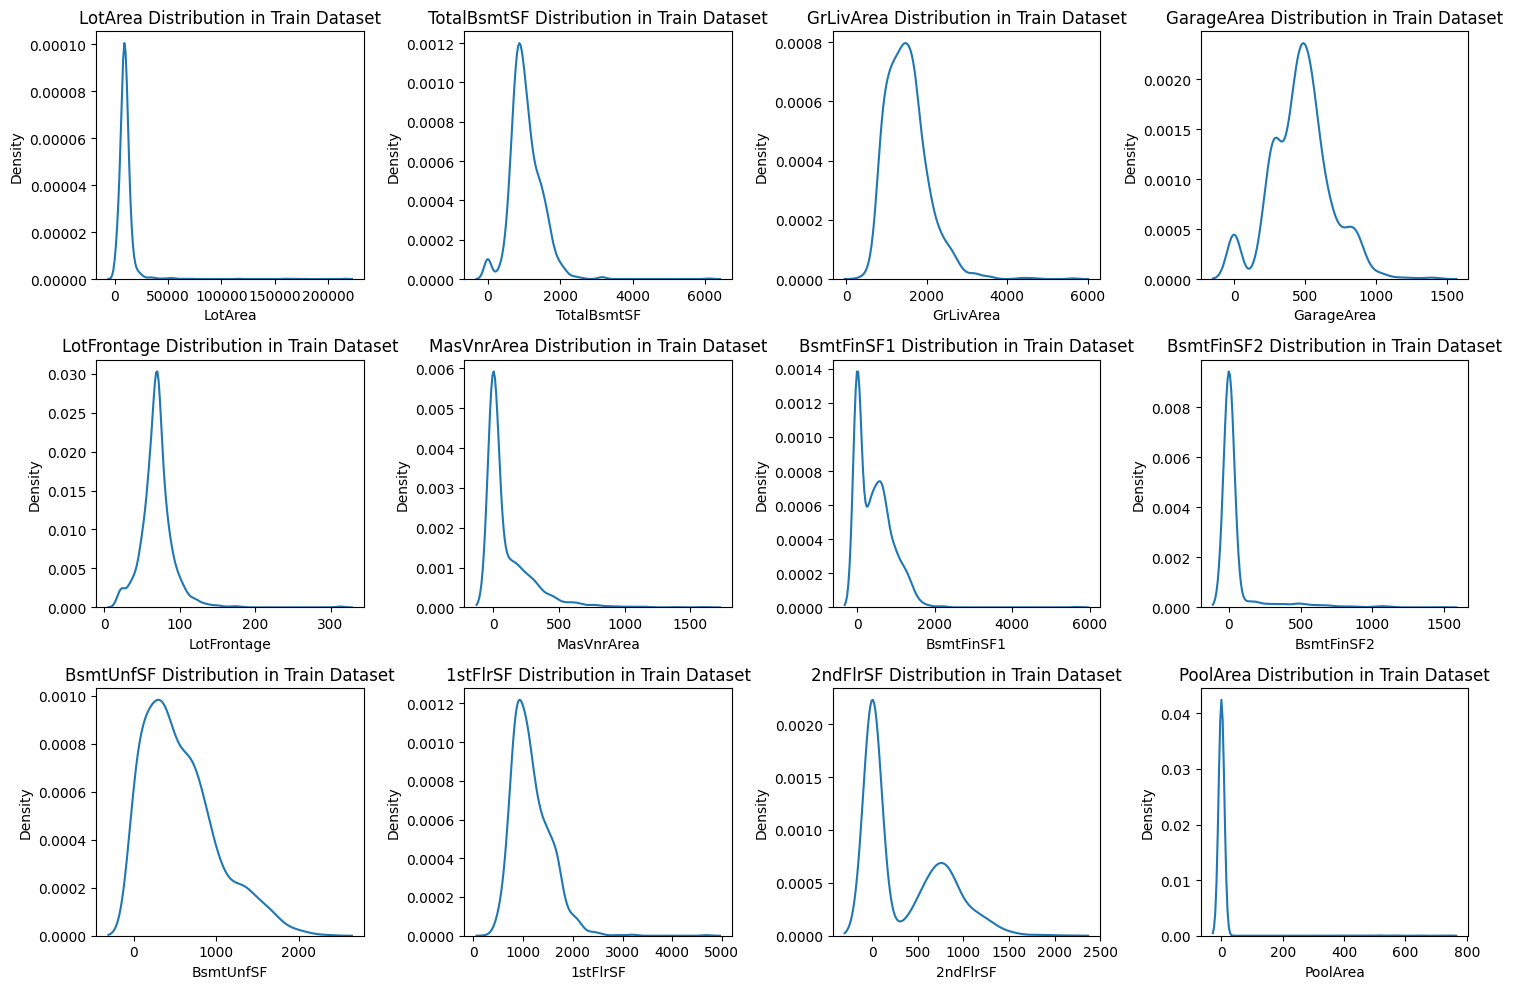

In [897]:
Area = ['LotArea','TotalBsmtSF','GrLivArea','GarageArea','LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
            'BsmtUnfSF', '1stFlrSF', '2ndFlrSF','PoolArea']
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize=(15,10))
index = 0
for row in range(len(axes)):
    for col in range(len(axes[row])):
        sns.kdeplot(train, x = Area[index], ax = axes[row][col])
        axes[row][col].set_title(f'{Area[index]} Distribution in Train Dataset')
        index +=1
        if index == len(Area):
            break
plt.tight_layout()

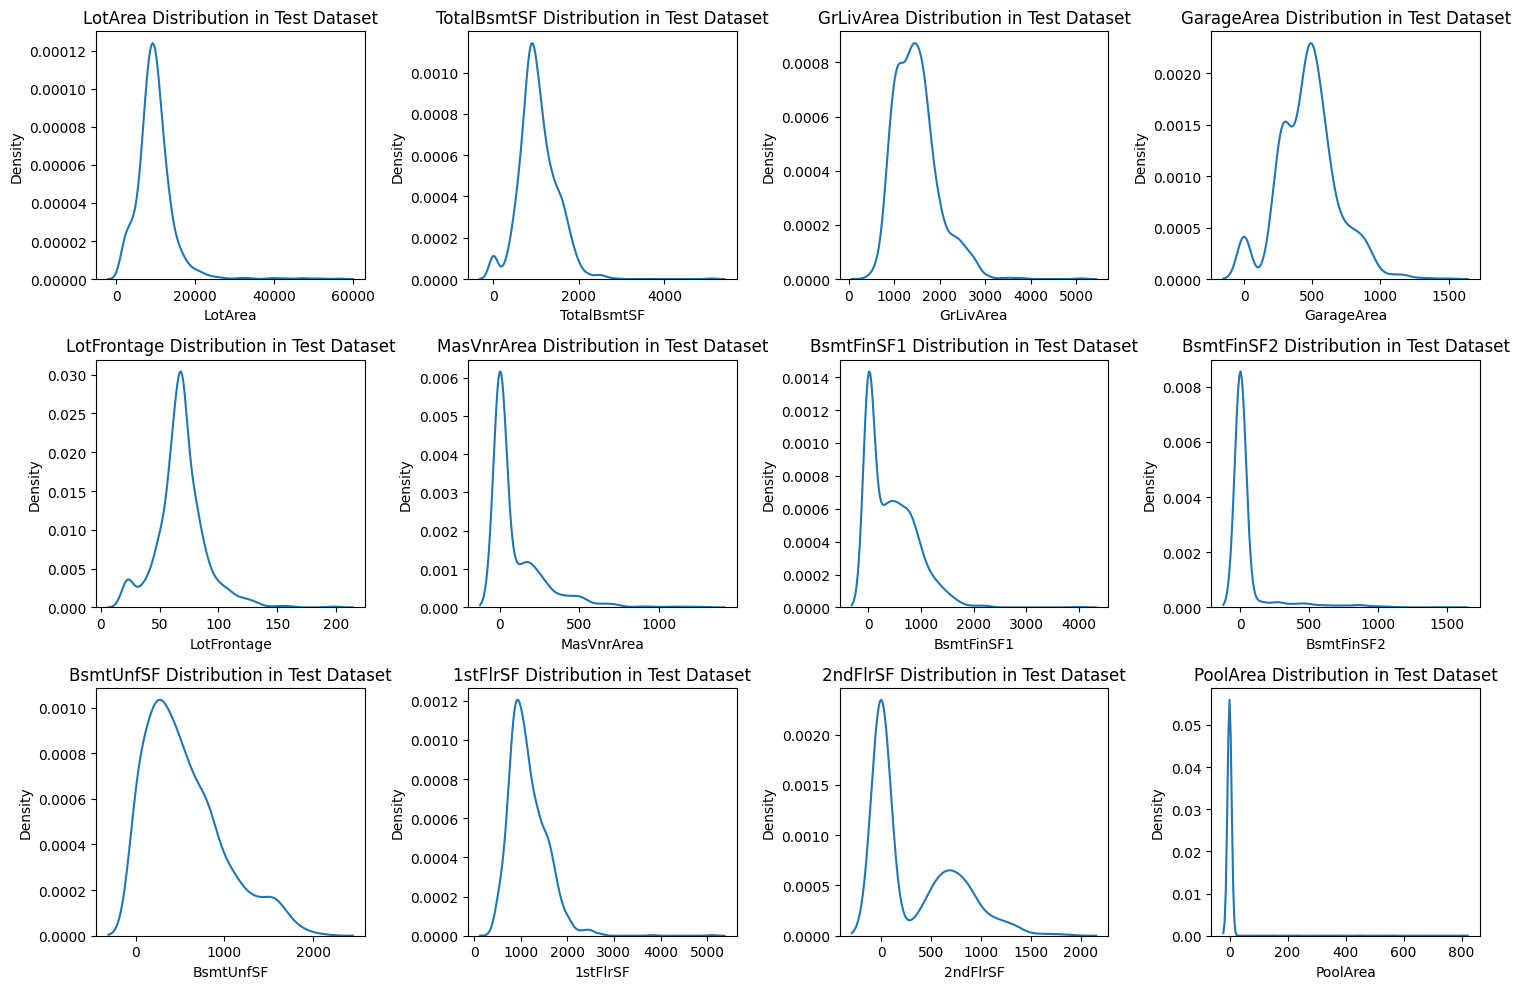

In [898]:
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize = (15,10))
index = 0
for row in range(len(axes)):
    for col in range(len(axes[row])):
        sns.kdeplot(test, x = Area[index], ax = axes[row][col])
        axes[row][col].set_title('{} Distribution in Test Dataset'.format(Area[index]))
        index +=1
        if index == len(Area):
            break
plt.tight_layout()
# it seems like there are no differences between test and train datasets

### Data Visualisation

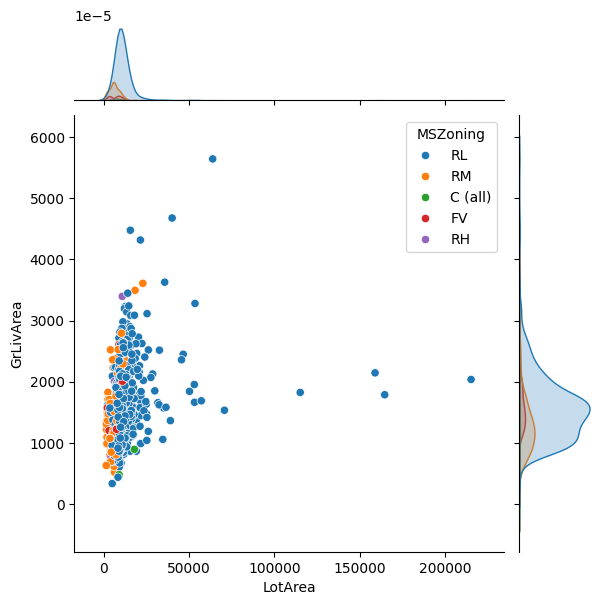

In [899]:
sns.jointplot(train, x = 'LotArea', y = 'GrLivArea', hue ='MSZoning')
# GrLivArea might be greater if LotArea is small, which means ground living area is ultilised 
# and built into building or many stories of a house
# Outliers might lie in LotArea with MSZoning RL

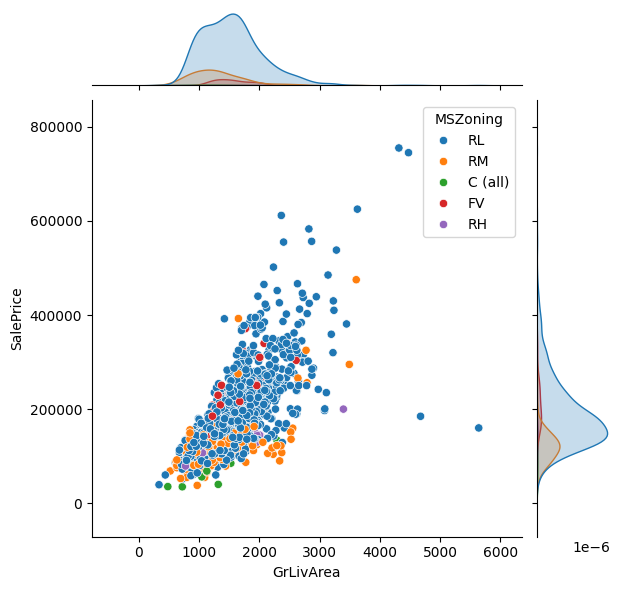

In [900]:
sns.jointplot(train, x = 'GrLivArea', y ='SalePrice', hue = 'MSZoning')

<Axes: xlabel='GrLivArea', ylabel='Count'>

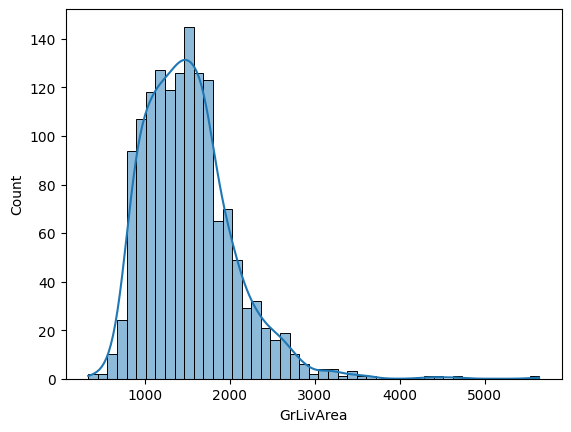

In [901]:
sns.histplot(train, x ='GrLivArea', kde = True)
# The Distribution is skewed to right, so there is a need to transform the shape of distribution
# to Gaussian distribution

<Axes: xlabel='LotArea', ylabel='Count'>

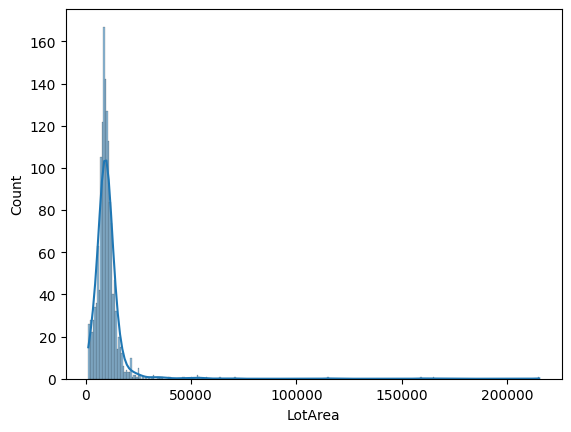

In [902]:
sns.histplot(train, x = 'LotArea', kde = True)
# The Distribution is skewed to right, so there is a need to transform the shape of distribution
# to Gaussian distribution

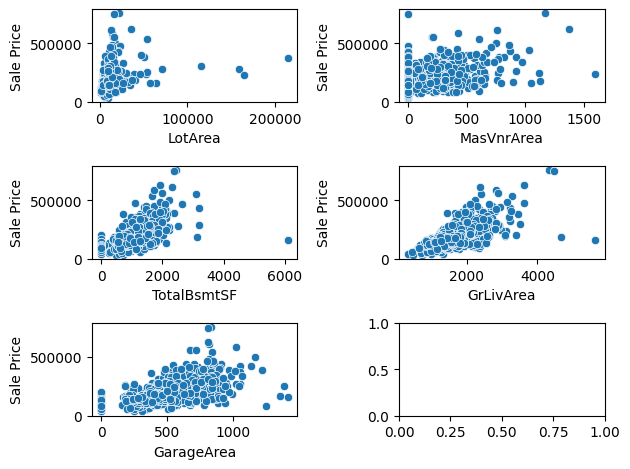

In [903]:
fig, ax = plt.subplots(nrows = 3, ncols = 2)
for index, col in enumerate(['LotArea','MasVnrArea','TotalBsmtSF','GrLivArea','GarageArea']):
    r = index // 2
    c = index % 2
    sns.scatterplot(data = train, x = col, y = 'SalePrice', ax = ax[r][c])
    ax[r][c].set_ylabel('Sale Price')
    plt.tight_layout()

Text(0, 0.5, 'House Sale Price')

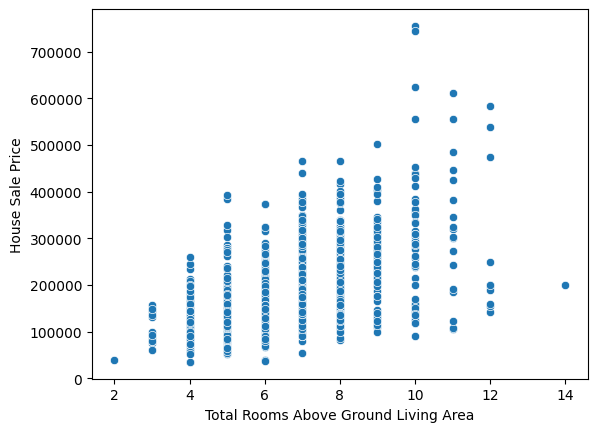

In [904]:
sns.scatterplot(train, x = 'TotRmsAbvGrd', y = 'SalePrice')
plt.xlabel('Total Rooms Above Ground Living Area')
plt.ylabel('House Sale Price')

In [905]:
def detect_outliers_iqr(df, feature):
    df[feature] = sorted(df[feature])
    q1 = np.percentile(df[feature], 25)
    q3 = np.percentile(df[feature], 75)
    IQR = q3 - q1
    lower_bound =q1 - (1.5 *IQR)
    upper_bound = q3 + (1.5*IQR)
    return lower_bound, upper_bound

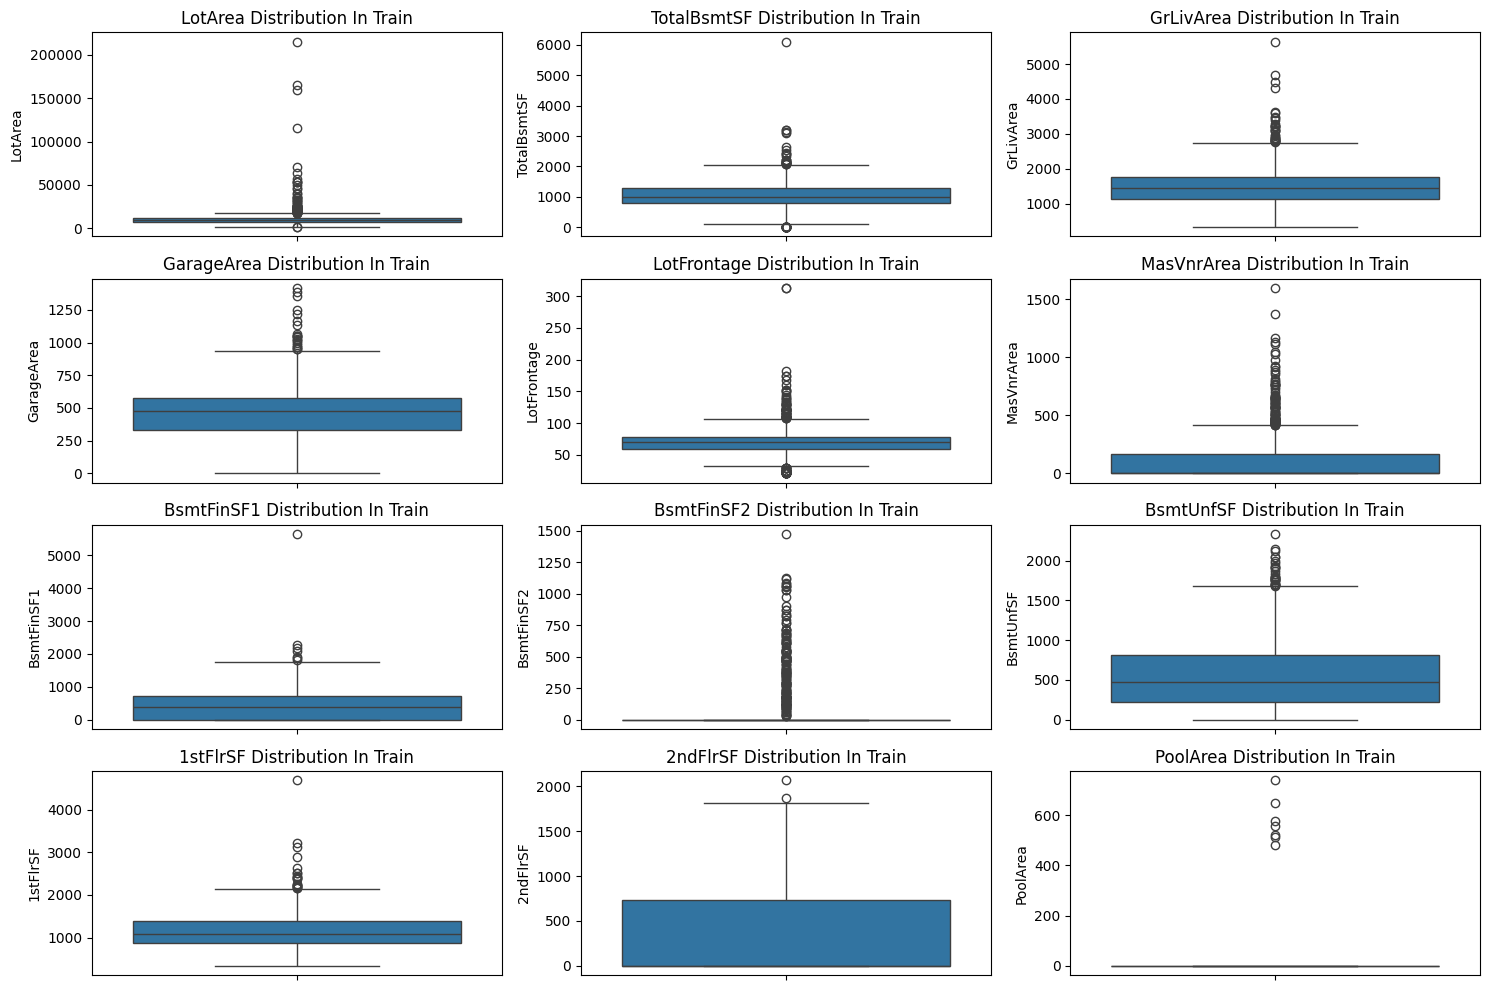

In [906]:
Area = ['LotArea','TotalBsmtSF','GrLivArea','GarageArea','LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
            'BsmtUnfSF', '1stFlrSF', '2ndFlrSF','PoolArea']
fig, ax = plt.subplots(nrows = 4, ncols = 3, figsize =(15,10))
index = 0
for row in range(len(ax)):
    for col in range(len(ax[row])):
        sns.boxplot(train, y = Area[index], ax = ax[row][col])
        ax[row][col].set_title(f'{Area[index]} Distribution In Train')
        index +=1
        plt.tight_layout()
        if index == len(Area):
            break

In [907]:
#Detect and remove outliers in Train Dataset
## LotArea
lower_bound, upper_bound = detect_outliers_iqr(train, 'LotArea')
train = train[(train['LotArea'] > lower_bound) & (train['LotArea'] < upper_bound)]
## GrLivArea
#lower_bound, upper_bound = detect_outliers_iqr(train, 'GrLivArea')
#train = train[(train['GrLivArea'] > lower_bound) & (train['GrLivArea'] < upper_bound)]
#TotRmsAbvGr
#train = train[(train['TotRmsAbvGrd'] > 2) & (train['TotRmsAbvGrd'] < 14)]

<Axes: ylabel='LotArea'>

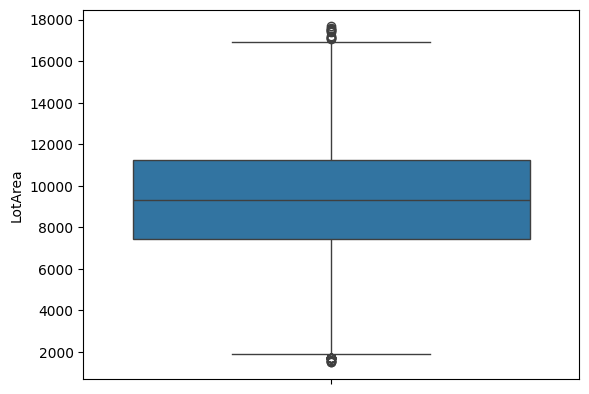

In [973]:
sns.boxplot(train, y = 'LotArea')

fig, ax = plt.subplots(nrows = 4, ncols = 3, figsize =(15,10))
index = 0
for row in range(len(ax)):
    for col in range(len(ax[row])):
        sns.boxplot(train, y = Area[index], ax = ax[row][col])
        ax[row][col].set_title(f'{Area[index]} Distribution After Removing Outliers')
        index +=1
        plt.tight_layout()
        if index == len(Area):
            break

fig, ax = plt.subplots(nrows = 4, ncols = 3, figsize =(15,10))
index = 0
for row in range(len(ax)):
    for col in range(len(ax[row])):
        sns.boxplot(test, y = Area[index], ax = ax[row][col])
        ax[row][col].set_title(f'{Area[index]} Distribution in Test')
        index +=1
        plt.tight_layout()
        if index == len(Area):
            break

<Axes: xlabel='MoSold', ylabel='count'>

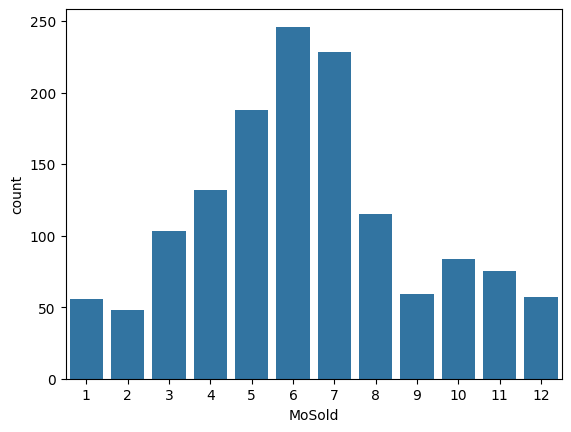

In [909]:
sns.countplot(train, x ='MoSold')

C:\Users\Rice\AppData\Local\Temp\ipykernel_17248\1682711807.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train, x = 'HouseStyle', palette = 'Set1')


<Axes: xlabel='HouseStyle', ylabel='count'>

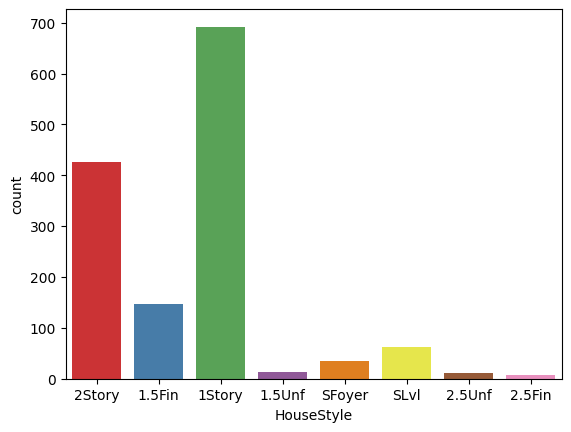

In [910]:
sns.countplot(train, x = 'HouseStyle', palette = 'Set1')
# 1Story is the most popular style of houses

<Axes: xlabel='OverallCond', ylabel='count'>

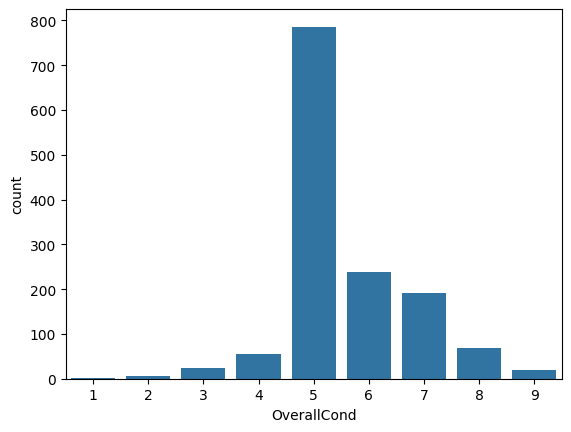

In [911]:
sns.countplot(train, x = 'OverallCond')

<Axes: xlabel='MSSubClass', ylabel='count'>

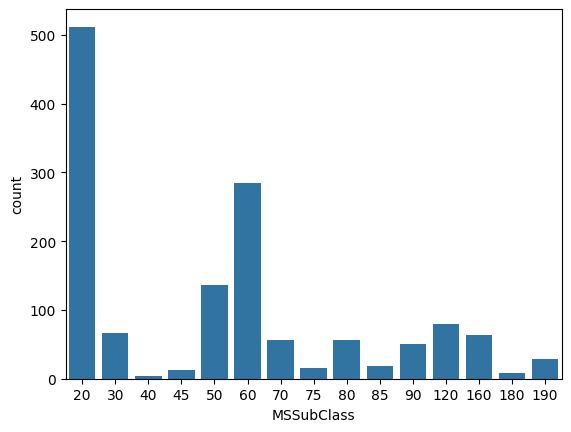

In [912]:
sns.countplot(train, x ='MSSubClass')
# Majority type of houses is 20  (1-STORY 1946 & NEWER ALL STYLES)

<Axes: xlabel='MSZoning', ylabel='count'>

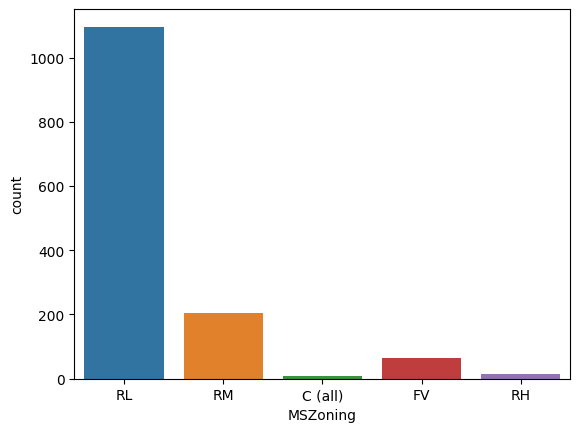

In [913]:
sns.countplot(train, x = 'MSZoning', hue = 'MSZoning')
# Most houses sold are in Residential Low Density

### Define the reasons why missing values in each column and the way to replace them
* Missing values in LotFrontage are because of not being recorded
    * Average the LotFrontage with conditions of MSZoning, MSSubclass (reject)
        * it seems like MSZoning and MSSubclass dont have any influence on LotFrontage
    * Average the LotFrontage and fill the missing values with the AVG
* In Alley, there is no clear evidence showing that values are missing because of lack of record 
* If values in MasVnrType are missing because the values dont exist
* If values in MasVnrArea are missing and values in MasVnrType are misisng/none because the values dont exist, 
* Missing values in BsmtQal, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2
having relationship with each other.
    * In particular, index 948, BsmtExposure is missing but other columns of Bsmt are filled
        * it is potential not recorded, therefore, it can be filled with the most frequent value (No)
* 1 missing value in Electrical is due to lack of record
* If values in Fireplace are 0 because the values might not exist
* GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond have relationship with each other, if values in one column are missing, they will also be missing in others
* Missing values in PoolQC, Fence, MiscFeature are because they might not exist

### Handle Category Variables before Regression Modelising
* One-hot coding for category variables having many values but not have any ordinal relationship
* Label Encoding will use for category variables having 2 values (CentralAir,PavedDrive, Street)
* With category variables having many values and they also have ordinal relationship 
(LotShape, LandContour, LandSlope, ExterQual,
ExterCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, HeatingQC, KitchenQual,
FireplaceQu, GarageQual, GarageCond, PoolQC)


In [914]:
def log_transformation(df, features, features_log):
    df[features] = df[features].replace(0, None)
    df[features] = df[features].astype(float)
    df[features_log] = np.log(df[features])
    df.drop(columns = features , axis = 1 , inplace = True )
    return df

In [915]:
features = ['LotArea','GrLivArea','GarageArea', 'BsmtFinSF1', '1stFlrSF', 'YearBuilt']

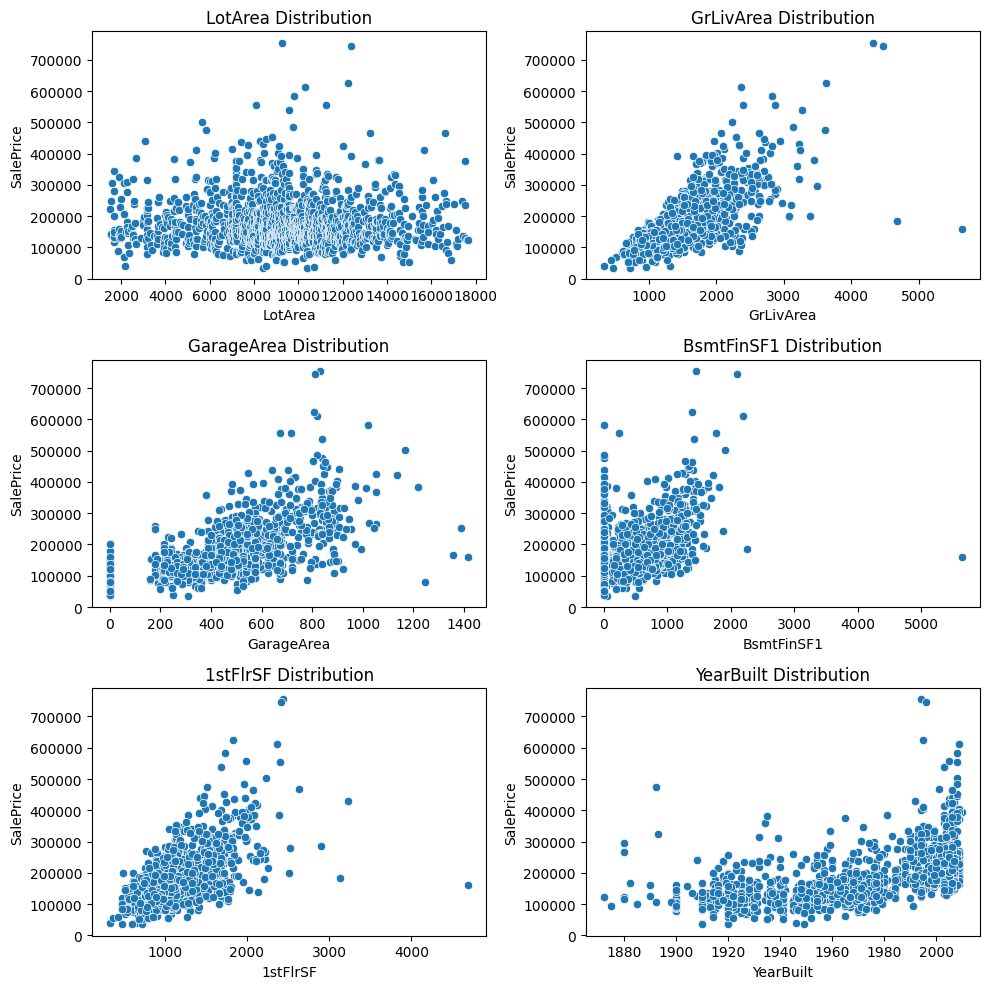

In [916]:
fig, axes = plt.subplots(nrows = 3, ncols = 2,figsize = (10,10))
index = 0
for row in range(len(axes)):
    for col in range(len(axes[row])):
        if index == len(features):
            break
        sns.scatterplot(train, x = features[index], y ='SalePrice', ax = axes[row][col])
        axes[row][col].set_title('{} Distribution'.format(features[index]))
        index +=1
plt.tight_layout()

In [917]:
category_features = ['MSZoning','LandContour','Utilities','LotConfig','Neighborhood','Condition1',
                     'Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType'
                     ,'Foundation','Heating','Electrical','Functional','GarageType','PavedDrive','PavedDrive',
                     'Fence','MiscFeature','SaleType','SaleCondition']
encoding_features = ['Street', 'Alley','CentralAir']
ordinal_features_15 = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual',
                       'FireplaceQu','GarageQual','GarageCond']
ordinal_features_05 = ['BsmtFinType1','BsmtFinType2',]
ordinal_features_13 = ['LandSlope']
ordinal_feature_02 =['GarageFinish']
ordinal_features_03 = ['LotShape','BsmtExposure',]
ordinal_features_25 = ['PoolQC']

In [918]:
#Encoding Lable
encoder = LabelEncoder()
for feature in encoding_features:
    train[feature] = encoder.fit_transform(train[feature])
    test[feature] = encoder.fit_transform(test[feature])

In [919]:
convert_scale_15 = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
convert_scale_05 = {'Unf': 0, 'LwQ': 1, 'Rec': 2, 'BLQ': 3, 'ALQ': 4, 'GLQ': 5}
convert_scale_LandSlope = {'Gtl': 1, 'Mod': 2, 'Sev': 3}
convert_scale_LotShape = {'Reg': 0, 'IR1': 1,'IR2': 2,'IR3': 3}
convert_scale_Finish = {'Fin':3,'RFn':2,'Unf':1}

In [920]:
train[ordinal_features_15] = train[ordinal_features_15].replace(convert_scale_15)
train[ordinal_features_05] = train[ordinal_features_05].replace(convert_scale_05)
train['LandSlope'] = train['LandSlope'].replace(convert_scale_LandSlope)
train['GarageFinish'] = train['GarageFinish'].replace(convert_scale_Finish)
train['LotShape'] = train['LotShape'].replace(convert_scale_LotShape)
train['PoolQC'] = train['PoolQC'].replace(convert_scale_15)

C:\Users\Rice\AppData\Local\Temp\ipykernel_17248\859084536.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[ordinal_features_15] = train[ordinal_features_15].replace(convert_scale_15)
C:\Users\Rice\AppData\Local\Temp\ipykernel_17248\859084536.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[ordinal_features_05] = train[ordinal_features_05].replace(convert_scale_05)
C:\Users\Rice\AppData\Local\Temp\ipykernel_17248\859084536.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in

In [921]:
test[ordinal_features_15] = test[ordinal_features_15].replace(convert_scale_15)
test[ordinal_features_05] = test[ordinal_features_05].replace(convert_scale_05)
test['LandSlope'] = test['LandSlope'].replace(convert_scale_LandSlope)
test['GarageFinish'] = test['GarageFinish'].replace(convert_scale_Finish)
test['LotShape'] = test['LotShape'].replace(convert_scale_LotShape)
test['PoolQC'] = test['PoolQC'].replace(convert_scale_15)

C:\Users\Rice\AppData\Local\Temp\ipykernel_17248\4080878357.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[ordinal_features_15] = test[ordinal_features_15].replace(convert_scale_15)
C:\Users\Rice\AppData\Local\Temp\ipykernel_17248\4080878357.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[ordinal_features_05] = test[ordinal_features_05].replace(convert_scale_05)
C:\Users\Rice\AppData\Local\Temp\ipykernel_17248\4080878357.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in 

In [968]:
features = ['GrLivArea', 'LotArea','1stFlrSF','TotalBsmtSF','YearBuilt']

In [1031]:
indie_vars = ['MSSubClass','LotFrontage','LotShape','LandSlope','FullBath'] + ordinal_features_15 + features

In [1032]:
X = train[indie_vars]
y = train['SalePrice']
test_X = test[indie_vars]
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size= 0.2)
house_model = RandomForestRegressor(random_state=0)
house_model.fit(X,y)
house_predictions = house_model.predict(test_X)
print('Training Score: {}'.format(house_model.score(train_X, train_y)))
print('Testing Score: {}'.format(house_model.score(test_X, test_y)))

Training Score: 0.9742188391460427
Testing Score: 0.9743380571872825


In [1028]:
print('The predictions of Price: {}'.format(house_predictions[0:5]))
print('RMSE: {}'.format(root_mean_squared_error(test_y, house_predictions)))
print('MAE: {}'.format(mean_absolute_error(test_y, house_predictions)))
print('MSE: {}'.format(mean_squared_error(test_y,house_predictions)))

The predictions of Price: [141247.5  121364.   302638.79 163979.32 320000.  ]
RMSE: 11024.076621253294
MAE: 7012.883189964158
MSE: 121530265.35126346


In [1033]:
test_X = test[indie_vars]
test_ID = test['Id']
output1 = pd.DataFrame({'Id': test_ID, 'SalePrice': house_model.predict(test_X)})
#output1.to_csv('submission05.csv', index = False)
print(output1.head())
print('\n',output1['SalePrice'].min())

     Id  SalePrice
0  1461  121209.50
1  1462  149404.00
2  1463  176515.32
3  1464  185901.50
4  1465  191164.44

 64699.1
